Using Colab cache for faster access to the 'valorant-dataset-v3' dataset.
Dataset: /kaggle/input/valorant-dataset-v3
                    player assists damage_received  headshots    tier  traded  \
0       Tie2åå®¹ä½#Tie2   2,828       1,692,848       6410    iron    1366   
1              takohr#3680   2,787       1,315,016       1879    iron    1157   
2                sino#1204   2,785       1,540,524       3287  bronze    1308   
3                sent#away   2,771       1,553,627       3174    iron    1423   
4  ããªã¢æ©Twitch#0625   2,596       1,621,822       2688    iron    1300   

   kills  matches  deaths   damage  
0   9702      667    9271  1832300  
1   4860      440    6893   978580  
2   7276      605    8329  1565588  
3   5446      614    8681  1071070  
4   6479      625    8839  1254742  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           

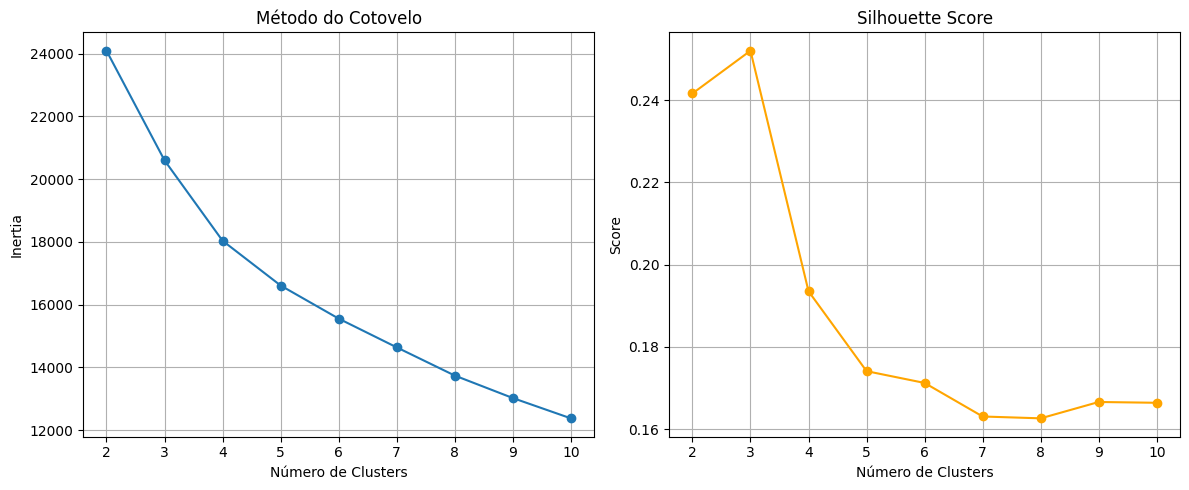


Melhor número de clusters: 3

Quantidade por Cluster:
cluster
1    1659
0     754
2     281
Name: count, dtype: int64

Médias dos Clusters:
           kills   deaths  assists      damage  damage_received  matches  \
cluster                                                                    
0        8171.71  8400.87  2821.75  1547940.64       1615212.46   529.77   
1        6358.04  6174.37  2023.20  1201113.27       1189762.95   389.15   
2        4626.44  5176.34  1707.51   876486.96        976837.62   345.09   

         tier  kd_ratio  headshot_ratio  damage_per_match  assist_per_match  \
cluster                                                                       
0        3.39      0.98            0.62           2928.24              5.35   
1        2.98      1.03            0.68           3095.75              5.21   
2        3.01      0.89            0.49           2538.09              4.94   

         traded_ratio  
cluster                
0                2.97  
1         

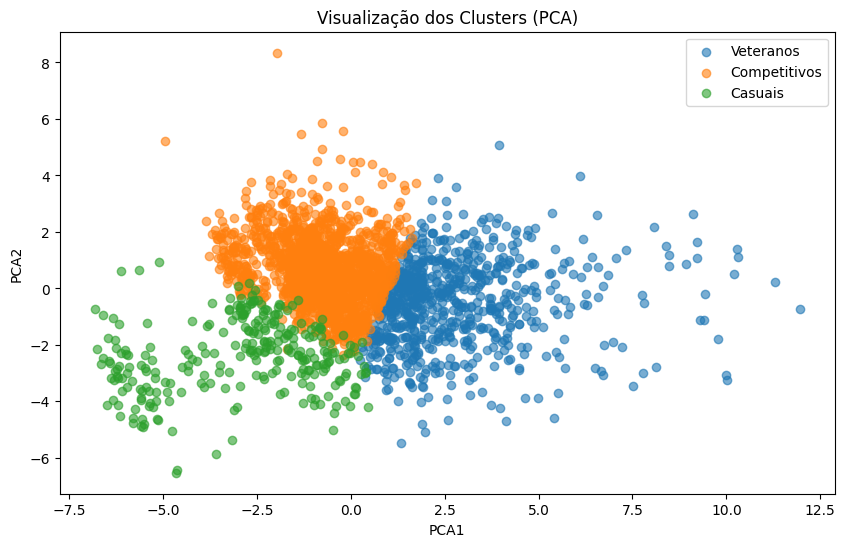


Melhor K para o KNN: 15 (Acurácia: 0.9759)


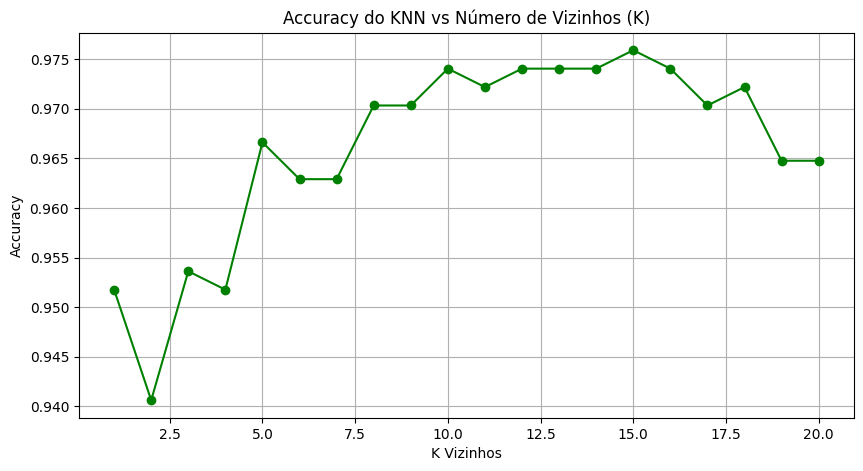


--- Relatório KNN ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       151
           1       0.97      1.00      0.98       332
           2       1.00      0.93      0.96        56

    accuracy                           0.98       539
   macro avg       0.99      0.96      0.97       539
weighted avg       0.98      0.98      0.98       539



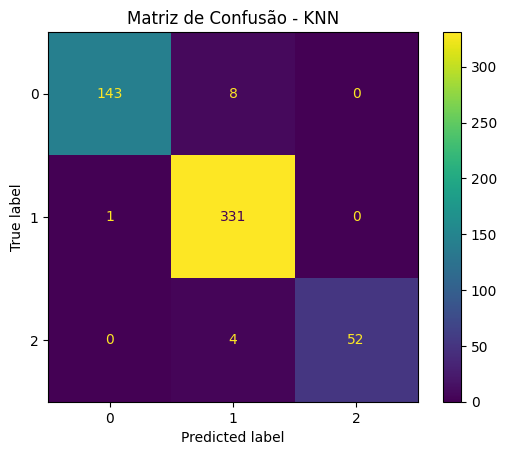


Melhor max_depth para a Árvore: 11 (Acurácia Teste: 0.9425)


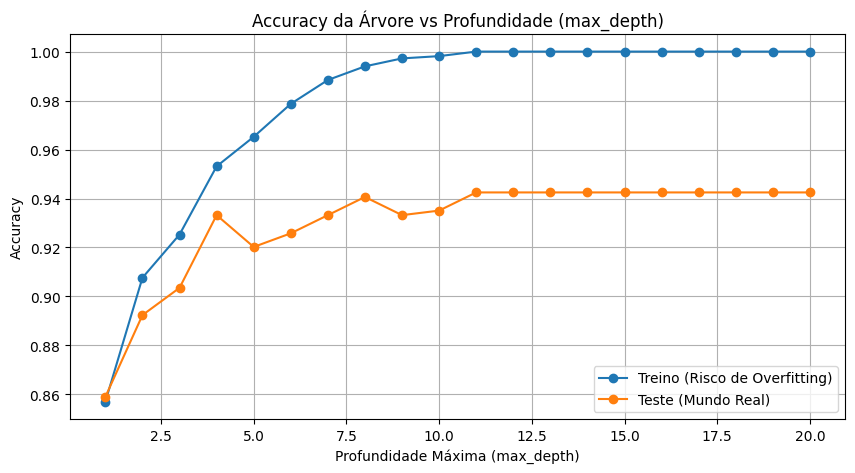


--- Relatório Decision Tree ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       151
           1       0.95      0.96      0.96       332
           2       0.86      0.89      0.88        56

    accuracy                           0.94       539
   macro avg       0.92      0.92      0.92       539
weighted avg       0.94      0.94      0.94       539



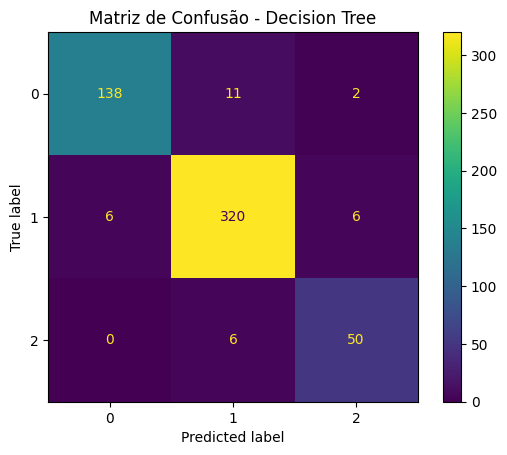

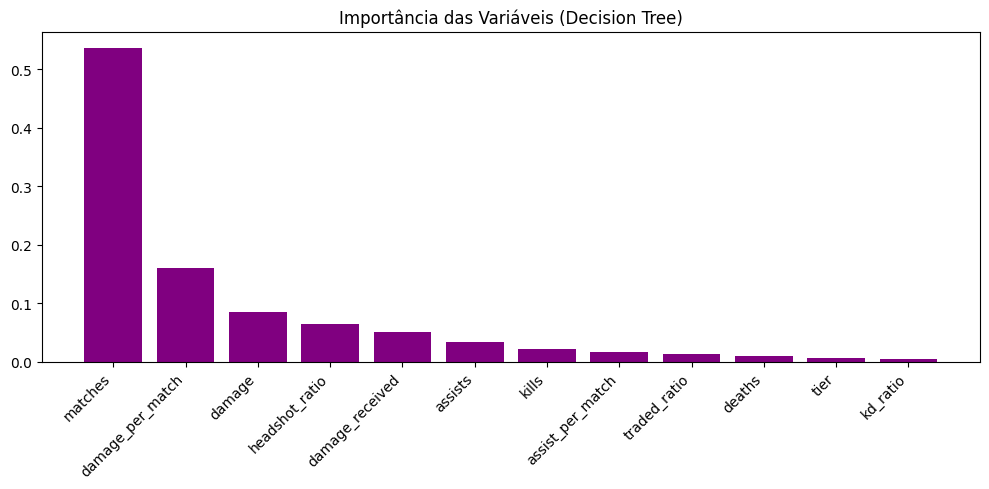

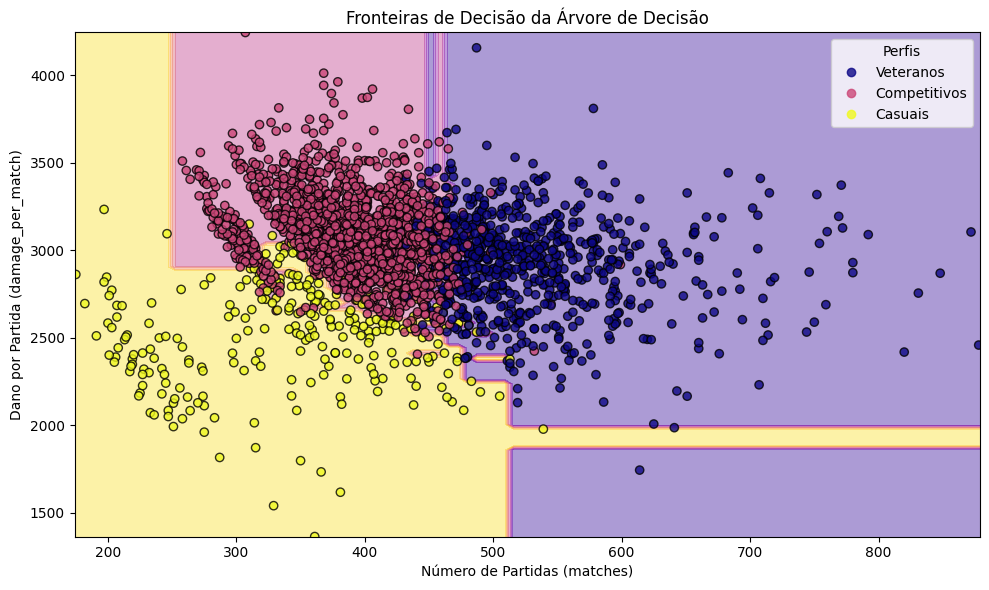

In [11]:
import pandas as pd
import numpy as np
import kagglehub
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

# =====================================================
# 1. DOWNLOAD E LEITURA
# =====================================================
path = kagglehub.dataset_download("notnguyen/valorant-dataset-v3")
print("Dataset:", path)

df = pd.read_csv(f"{path}/valorant_dataset_v3.csv")
print(df.head())
print(df.info())

# =====================================================
# 2. LIMPEZA
# =====================================================
print("\nValores nulos:")
print(df.isnull().sum())

df = df.drop(columns=["player"])

colunas_numericas = [
    "assists", "damage_received", "headshots", "traded",
    "kills", "matches", "deaths", "damage"
]

for col in colunas_numericas:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

# =====================================================
# 3. LABEL ENCODER
# =====================================================
le = LabelEncoder()
df["tier"] = le.fit_transform(df["tier"])

# =====================================================
# 4. FEATURE ENGINEERING
# =====================================================
df["deaths"] = df["deaths"].replace(0, 1)
df["kills"] = df["kills"].replace(0, 1)
df["matches"] = df["matches"].replace(0, 1)

df["kd_ratio"] = df["kills"] / df["deaths"]
df["headshot_ratio"] = df["headshots"] / df["kills"]
df["damage_per_match"] = df["damage"] / df["matches"]
df["assist_per_match"] = df["assists"] / df["matches"]
df["traded_ratio"] = df["traded"] / df["matches"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

# =====================================================
# 5. FEATURES E NORMALIZAÇÃO
# =====================================================
features = [
    "kills", "deaths", "assists", "damage", "damage_received",
    "matches", "tier", "kd_ratio", "headshot_ratio",
    "damage_per_match", "assist_per_match", "traded_ratio"
]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nBase pronta! Shape:", X.shape)

# =====================================================
# 6. SALVAR BASES TRATADAS
# =====================================================
df.to_csv("valorant_dataset_tratado.csv", index=False)
pd.DataFrame(X_scaled, columns=features).to_csv("valorant_dataset_normalizado.csv", index=False)

# =====================================================
# 7. K-MEANS: MÉTODO DO COTOVELO E SILHOUETTE
# =====================================================
inertia = []
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    score = silhouette_score(X_scaled, clusters)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette={score:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker="o", color="orange")
plt.title("Silhouette Score")
plt.xlabel("Número de Clusters")
plt.ylabel("Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 8. K-MEANS: APLICAÇÃO DO MELHOR K
# =====================================================
melhor_cluster = np.argmax(silhouette_scores) + 2
print(f"\nMelhor número de clusters: {melhor_cluster}")

kmeans = KMeans(n_clusters=melhor_cluster, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

nomes_clusters = {0: "Veteranos", 1: "Competitivos", 2: "Casuais"}

print("\nQuantidade por Cluster:")
print(df["cluster"].value_counts())

print("\nMédias dos Clusters:")
print(df.groupby("cluster")[features].mean().round(2))

# =====================================================
# 9. PCA (VISUALIZAÇÃO)
# =====================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("\nVariância explicada pelo PCA:", pca.explained_variance_ratio_)
print("Variância total preservada:", round(pca.explained_variance_ratio_.sum(), 4))

pca_df = pd.DataFrame({"PCA1": X_pca[:, 0], "PCA2": X_pca[:, 1], "cluster": df["cluster"]})

plt.figure(figsize=(10, 6))
for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PCA1"], subset["PCA2"], alpha=0.6, label=nomes_clusters[cluster])

plt.title("Visualização dos Clusters (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.show()

# =====================================================
# 10. PREPARAÇÃO PARA APRENDIZADO SUPERVISIONADO
# =====================================================
y = df["cluster"]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

# =====================================================
# 11. KNN: OTIMIZAÇÃO E TREINAMENTO
# =====================================================
knn_scores = []
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    knn_scores.append(accuracy_score(y_test, knn_temp.predict(X_test)))

melhor_k = np.argmax(knn_scores) + 1
print(f"\nMelhor K para o KNN: {melhor_k} (Acurácia: {max(knn_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), knn_scores, marker="o", color="green")
plt.title("Accuracy do KNN vs Número de Vizinhos (K)")
plt.xlabel("K Vizinhos")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

knn = KNeighborsClassifier(n_neighbors=melhor_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("\n--- Relatório KNN ---")
print(classification_report(y_test, knn_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred)).plot()
plt.title("Matriz de Confusão - KNN")
plt.show()

# =====================================================
# 12. DECISION TREE: OTIMIZAÇÃO (NOVO GRÁFICO)
# =====================================================
tree_scores_train = []
tree_scores_test = []
profundidades = range(1, 21)

for d in profundidades:
    tree_temp = DecisionTreeClassifier(random_state=42, max_depth=d)
    tree_temp.fit(X_train, y_train)
    tree_scores_train.append(accuracy_score(y_train, tree_temp.predict(X_train)))
    tree_scores_test.append(accuracy_score(y_test, tree_temp.predict(X_test)))

melhor_depth = profundidades[np.argmax(tree_scores_test)]
print(f"\nMelhor max_depth para a Árvore: {melhor_depth} (Acurácia Teste: {max(tree_scores_test):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(profundidades, tree_scores_train, marker="o", label="Treino (Risco de Overfitting)")
plt.plot(profundidades, tree_scores_test, marker="o", label="Teste (Mundo Real)")
plt.title("Accuracy da Árvore vs Profundidade (max_depth)")
plt.xlabel("Profundidade Máxima (max_depth)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# 13. DECISION TREE: TREINAMENTO FINAL
# =====================================================
tree = DecisionTreeClassifier(random_state=42, max_depth=melhor_depth)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

print("\n--- Relatório Decision Tree ---")
print(classification_report(y_test, tree_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, tree_pred)).plot()
plt.title("Matriz de Confusão - Decision Tree")
plt.show()

# Importância das Variáveis
importancias = pd.DataFrame({"Feature": features, "Importancia": tree.feature_importances_})
importancias = importancias.sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importancias["Feature"], importancias["Importancia"], color="purple")
plt.xticks(rotation=45, ha='right')
plt.title("Importância das Variáveis (Decision Tree)")
plt.tight_layout()
plt.show()

# =====================================================
# 13.5 FRONTEIRAS DE DECISÃO (VISUALIZAÇÃO 2D)
# =====================================================

X_vis = df[["matches", "damage_per_match"]]
y_vis = df["cluster"]

# árvore auxiliar apenas para o gráfico
tree_vis = DecisionTreeClassifier(random_state=42, max_depth=melhor_depth)
tree_vis.fit(X_vis, y_vis)

fig, ax = plt.subplots(figsize=(10, 6))

# Desenha o fundo
DecisionBoundaryDisplay.from_estimator(
    tree_vis,
    X_vis,
    response_method="predict",
    alpha=0.4,
    cmap="plasma",
    ax=ax,
    xlabel="Número de Partidas (matches)",
    ylabel="Dano por Partida (damage_per_match)"
)

# Plota os jogadores
scatter = ax.scatter(
    X_vis["matches"],
    X_vis["damage_per_match"],
    c=y_vis,
    edgecolor="k",
    cmap="plasma",
    alpha=0.8
)

plt.title("Fronteiras de Decisão da Árvore de Decisão")

# Configura a legenda
legend_labels = [nomes_clusters[i] for i in sorted(nomes_clusters.keys())]
handles, _ = scatter.legend_elements()
ax.legend(handles, legend_labels, title="Perfis", loc="best")

plt.tight_layout()
plt.show()

Este código realiza as seguintes etapas:

### 1. Importação de Bibliotecas

- `pandas` e `numpy`: São usadas para manipulação e análise de dados.
- `kagglehub`: Permite baixar conjuntos de dados diretamente do Kaggle.
- `sklearn.preprocessing.LabelEncoder`: Usado para converter rótulos categóricos em valores numéricos.
- `sklearn.preprocessing.StandardScaler`: Usado para padronizar as características (recursos) do dataset, uma etapa comum no pré-processamento para modelos de Machine Learning.

### 2. Download do Dataset

- O dataset `valorant-dataset-v3` é baixado do Kaggle para um diretório temporário no ambiente Colab. O caminho para este diretório é armazenado na variável `path`.

### 3. Carregamento e Inspeção Inicial dos Dados

- O arquivo `valorant_dataset_v3.csv` é lido do diretório baixado e carregado em um DataFrame do pandas chamado `df`.
- `df.head()`: Exibe as primeiras 5 linhas do DataFrame.
- `df.info()`: Fornece um resumo conciso do DataFrame, incluindo o tipo de dado de cada coluna e a contagem de valores não nulos.
- `df.isnull().sum()`: Mostra a contagem de valores nulos para cada coluna.

### 4. Limpeza Inicial e Conversão de Tipos

- `df = df.drop(columns=["player"])`: A coluna 'player' é removida, pois provavelmente não é útil para o modelo de Machine Learning.
- Um loop percorre as `colunas_numericas` identificadas. Para cada coluna:
    - `df[col] = df[col].astype(str).str.replace(",", "")`: Vírgulas são removidas dos valores (que inicialmente são tratados como strings) para que possam ser convertidos em números.
    - `df[col] = pd.to_numeric(df[col])`: Converte a coluna para o tipo numérico (inteiro ou float).
- `print(df.isnull().sum())`: Verifica novamente a contagem de nulos após a conversão de tipos.
- `df = df.dropna()`: Remove quaisquer linhas que ainda contenham valores nulos (que podem ter surgido de conversões com erros, por exemplo).

### 5. Engenharia de Características (Feature Engineering)

- `le = LabelEncoder()`: Inicializa um `LabelEncoder`.
- `df["tier"] = le.fit_transform(df["tier"])`: A coluna 'tier' (que provavelmente contém categorias como 'iron', 'bronze', etc.) é convertida em valores numéricos usando `LabelEncoder`.
- `df["deaths"] = df["deaths"].replace(0, 1)`: Zeros na coluna 'deaths' são substituídos por 1 para evitar erros de divisão por zero em cálculos subsequentes (como KD ratio).
- Novas características são criadas:
    - `kd_ratio`: Taxa de kills por mortes (`kills / deaths`).
    - `headshot_ratio`: Taxa de headshots por kills (`headshots / kills`).
    - `damage_per_match`: Dano médio por partida (`damage / matches`).
    - `assist_per_match`: Assistências médias por partida (`assists / matches`).
    - `traded_ratio`: Taxa de trocas (traded) por partidas (`traded / matches`).
- `df.replace([np.inf, -np.inf], np.nan, inplace=True)`: Substitui quaisquer valores infinitos (resultantes de divisões por zero antes da correção ou outras operações) por `NaN`.
- `df = df.dropna()`: Remove linhas que agora contêm `NaN` devido aos infinitos.

### 6. Seleção e Escala de Características

- `features`: Uma lista é definida com as colunas que serão usadas como características para o modelo de Machine Learning.
- `X = df[features]`: Um novo DataFrame `X` é criado contendo apenas as colunas selecionadas.
- `scaler = StandardScaler()`: Inicializa um `StandardScaler`.
- `X_scaled = scaler.fit_transform(X)`: Os dados em `X` são padronizados (escalados) para ter média 0 e desvio padrão 1. Isso é importante para muitos algoritmos de Machine Learning.

### 7. Saída e Salvamento de Dados

- `print("Base pronta para IA!")`: Mensagem de confirmação.
- `print(X.shape)`: Exibe as dimensões do DataFrame de características.
- `print(features)`: Lista as características usadas.
- `print(X_scaled[:5])`: Exibe as primeiras 5 linhas dos dados escalados.
- `df.to_csv("valorant_dataset_tratado.csv", index=False)`: O DataFrame original `df` (agora limpo e com as novas características) é salvo em um arquivo CSV.
- `X_scaled_df = pd.DataFrame(X_scaled, columns=features)`: Os dados escalados são convertidos de volta para um DataFrame, mantendo os nomes das colunas.
- `X_scaled_df.to_csv("valorant_dataset_normalizado.csv", index=False)`: O DataFrame com os dados padronizados é salvo em outro arquivo CSV.
- `print("Arquivos salvos com sucesso!")`: Mensagem final de confirmação.